In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../Mech_Interp/llm-transparency-tool')

%matplotlib inline

In [2]:
# Typeguard monkey patch

import typeguard

def no_op_typechecked(target=None, **kwargs):
    if target is not None and callable(target):
        return target
    def wrapper(func):
        return func
    return wrapper

typeguard.typechecked = no_op_typechecked

In [3]:
import torch
import numpy as np
import faiss
import collections
from typing import Dict, List, Tuple
import json
from tqdm.auto import tqdm
import warnings
import os
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig, AutoModelForCausalLM
from notebooks.utils import create_prompts_nq, generate_batch, load_llama
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

import llm_transparency_tool.models.tlens_model as tlens_model_module
import llm_transparency_tool.routes.contributions as contributions
from llm_transparency_tool.models.tlens_model import TransformerLensTransparentLlm

warnings.filterwarnings("ignore", category=UserWarning)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
# TransformerLens monkey patch

from transformer_lens import HookedTransformer

if not hasattr(HookedTransformer, "_original_set_use_attn_in"):
    HookedTransformer._original_set_use_attn_in = HookedTransformer.set_use_attn_in

    def safe_set_use_attn_in(self, use_attn_in):
        # If model uses GQA (n_key_value_heads is set) and we are just trying to disable attn_in
        if self.cfg.n_key_value_heads is not None and not use_attn_in:
            return # Silently skip to avoid Assertion Error
        # Otherwise run original logic
        return self._original_set_use_attn_in(use_attn_in)

    HookedTransformer.set_use_attn_in = safe_set_use_attn_in

In [5]:
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct" 
N_LAYERS = 16
N_HEADS = 32
CONTRIBUTION_THRESHOLD = 0.03
DATASET_ID = "florin-hf/nq_open_gold" 
BATCH_SIZE = 16
MAX_IFR_SAMPLES = 25
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

In [6]:
def get_target_token_id(tokenizer, answer: str) -> int:
    """Tokenizes the answer and returns the ID of the first token."""
    encoded_answer = tokenizer.encode(answer, add_special_tokens=False)
    if not encoded_answer:
        raise ValueError("Could not tokenize the target answer.")
    return encoded_answer[0]


def construct_prompts(question: str, context: str) -> Tuple[str, str]:
    """Creates the RAG and Non-RAG prompt templates."""
    # RAG (Open-Book) Prompt
    rag_prompt = (
        f"Context: {context}\n\n"
        f"Question: {question}\n\n"
        f"Answer:"
    )
    # Non-RAG (Closed-Book) Prompt
    non_rag_prompt = (
        f"Question: {question}\n\n"
        f"Answer:"
    )
    return rag_prompt, non_rag_prompt

def get_important_heads_from_text(model: TransformerLensTransparentLlm, text: str) -> List[Tuple[int, int]]:
    """
    Exact implementation of the reference logic to find important heads.
    """
    model._model.reset_hooks()
    model.run(text)

    tokens = model._model.to_tokens(text)
    tokens_size = tokens.shape[-1]
    
    # Generate all source->target pairs (causal masking)
    pos_idx_pairs = [(src, tgt) for src in range(tokens_size) for tgt in range(src, tokens_size)]
    
    important_heads = []
    
    for layer in range(N_LAYERS):
        head_contrib, c_resid_attn = contributions.get_attention_contributions(
            resid_pre=model.residual_in(layer)[0].unsqueeze(0),
            resid_mid=model.residual_after_attn(layer)[0].unsqueeze(0),
            decomposed_attn=model.decomposed_attn(0, layer).unsqueeze(0),
        )
        for src_token_idx, target_token_idx in pos_idx_pairs:
            # Calculate contributions using LLM-TT
            
            # Extract contribution vector for this specific token pair
            flat_contrib = head_contrib[0, target_token_idx, src_token_idx, :]
            
            # Apply threshold exactly as in reference
            important_head_idx = torch.nonzero(flat_contrib > CONTRIBUTION_THRESHOLD, as_tuple=False).squeeze(-1).tolist()
            
            if important_head_idx != []:
                # Ensure it's a list even if single element
                if isinstance(important_head_idx, int):
                    important_head_idx = [important_head_idx]
                    
                for head_idx in important_head_idx:
                    # Store as unique set to avoid duplicates per prompt, or keep duplicates if tracking frequency
                    # Reference code appends, so we append.
                    important_heads.append((layer, head_idx))
                    
    return important_heads


In [7]:
ds = load_dataset(DATASET_ID, split="validation")

df = pd.DataFrame({
    'question': ds['question'],
    'answers': ds['answers'], # List of valid answers
    'context': ds['text']     # The Gold Paragraph
})

In [8]:
# hf_model = AutoModelForCausalLM.from_pretrained(
#         MODEL_NAME,
#         torch_dtype=torch.bfloat16,
#         device_map="auto" 
#     )
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer, hf_model = load_llama(MODEL_NAME, quantize=False)

# Initialize wrapper with the pre-loaded optimized model
model = TransformerLensTransparentLlm(
    model_name=MODEL_NAME,
    hf_model=None,
    tokenizer=None,
    device="gpu" if torch.cuda.is_available() else "cpu",
    dtype=torch.bfloat16
)

In [9]:
def normalize_answer(text: str) -> str:
    def remove_articles(t): return re.sub(r"\b(a|an|the)\b", " ", t)
    def white_space_fix(t): return " ".join(t.split())
    def remove_punc(t): return "".join(ch for ch in t if ch not in set(string.punctuation))
    def lower(t): return t.lower()
    return white_space_fix(remove_articles(remove_punc(lower(text))))


def calculate_exact_match(prediction: str, ground_truths: List[str]) -> int:
    norm_pred = normalize_answer(prediction)
    return int(any(norm_pred == normalize_answer(gt) for gt in ground_truths))


def get_rag_success_cases(eval_model, tokenizer, dataset_id: str, batch_size: int) -> pd.DataFrame:
    ds = load_dataset(dataset_id, split="validation")
    df = pd.DataFrame({"question": ds["question"], "answers": ds["answers"], "context": ds["text"]})
    all_preds_no_rag, all_preds_rag = [], []

    for i in tqdm(range(0, len(df), batch_size), desc="Evaluating EM (RAG vs No-RAG)"):
        batch = df.iloc[i:i + batch_size]
        questions = batch["question"].tolist()
        contexts = batch["context"].tolist()

        prompts_no_rag = create_prompts_nq(tokenizer, questions, contexts=None)
        preds_no_rag = generate_batch(eval_model, tokenizer, prompts_no_rag)
        all_preds_no_rag.extend(p.replace("Answer:", "").strip() for p in preds_no_rag)

        prompts_rag = create_prompts_nq(tokenizer, questions, contexts=contexts)
        preds_rag = generate_batch(eval_model, tokenizer, prompts_rag)
        all_preds_rag.extend(p.replace("Answer:", "").strip() for p in preds_rag)

    df["pred_no_rag"] = all_preds_no_rag
    df["pred_rag"] = all_preds_rag
    df["em_no_rag"] = df.apply(lambda row: calculate_exact_match(row["pred_no_rag"], row["answers"]), axis=1)
    df["em_rag"] = df.apply(lambda row: calculate_exact_match(row["pred_rag"], row["answers"]), axis=1)

    success_df = df[(df["em_rag"] == 1) & (df["em_no_rag"] == 0)].reset_index(drop=True)
    if success_df.empty:
        raise ValueError("No samples where RAG succeeded and No-RAG failed.")
    return success_df

# rag_success_cases = get_rag_success_cases(hf_model, tokenizer, DATASET_ID, BATCH_SIZE)

In [10]:
# rag_success_cases.to_pickle("outputs/rag_success_cases_llama_3_1_1b_nq.pkl")
rag_success_cases = pd.read_pickle("outputs/rag_success_cases_llama_3_1_1b_nq.pkl")

In [11]:
rag_success_cases

,question,answers,context,pred_no_rag,pred_rag,em_no_rag,em_rag
0,who sings does he love me with reba,[Linda Davis],'' Does He Love You '' is a song written by Sa...,Reba McEntire,Linda Davis,0,1
1,who was the creator of victoria's secret,[Roy Raymond],"Victoria 's Secret Victoria 's Secret Store , ...",Robert Duffy,Roy Raymond,0,1
2,who introduced the system of civil services in...,[Charles Cornwallis],Warren Hastings laid the foundation of civil s...,Rajendra Prasad,Charles Cornwallis,0,1
3,southern soul was considered the sound of what...,[Motown],The key subgenres of soul include the Detroit ...,Warner Bros.,Motown,0,1
4,which apostle had a thorn in his side,[Paul],Thorn in the flesh is a phrase of New Testamen...,Peter,Paul,0,1
...,...,...,...,...,...,...,...
2691,when was netball first in the commonwealth games,[1998],Netball is one of the sports at the quadrennia...,1956,1998,0,1
2692,when was civil peace by chinua achebe published,[1971],'' Civil Peace '' is a 1971 short story by Chi...,1966,1971,0,1
2693,where is sperm made in the human body,[testicles],Sperm is the male reproductive cell and is der...,Ovary,Testicles,0,1
2694,when did sunday became the seventh day of the ...,[1988],The international standard ISO 8601 for repres...,Wednesday,1988,0,1


In [ ]:
def save_and_print_top_heads(counter, title):
    if len(counter) > 0:
        sorted_heads = sorted(counter.items(), key=lambda item: item[1], reverse=True)
        
        print("\n" + "="*80)
        print(title)
        print("="*80)
        print(f"{'Layer':<5} {'Head':<5} {'Frequency':<12}")
        print("-" * 35)
        for (layer, head), count in sorted_heads[:15]:
            print(f"{layer:<5} {head:<5} {count:<12}")
        
        return {f"L{l}_H{h}": count for (l, h), count in sorted_heads}
    return {}

In [ ]:
data_sample = (
    rag_success_cases
        .assign(context_len=rag_success_cases["context"].str.len())
        .sort_values("context_len", ascending=True)
        .head(100)
        .drop(columns="context_len")
        .reset_index(drop=True)
).to_dict(orient='records')

# Counters for different analysis modes
rag_unique_heads_counter = collections.defaultdict(int)
rag_total_counter = collections.defaultdict(int)
non_rag_total_counter = collections.defaultdict(int)

for i, sample in enumerate(tqdm(data_sample)):
    question = sample['question']
    context = sample['context'] 
    
    # try:
    rag_prompt, non_rag_prompt = construct_prompts(question, context)
    
    # # # --- Get Important Heads for RAG ---
    rag_heads = get_important_heads_from_text(model, rag_prompt)
    rag_heads_set = set(rag_heads)
    
    # --- Get Important Heads for Non-RAG ---
    non_rag_heads = get_important_heads_from_text(model, non_rag_prompt)
    non_rag_heads_set = set(non_rag_heads)
    
    # # --- 1. Total RAG Analysis ---
    for (layer, head) in rag_heads_set:
        rag_total_counter[(layer, head)] += 1

    # --- 2. Total Non-RAG Analysis ---
    for (layer, head) in non_rag_heads_set:
        non_rag_total_counter[(layer, head)] += 1

    # --- 3. Differential Analysis (Unique to RAG) ---
    # Find heads that are "Important" in RAG but NOT in Non-RAG
    unique_rag_heads = rag_heads_set - non_rag_heads_set
    for (layer, head) in unique_rag_heads:
        rag_unique_heads_counter[(layer, head)] += 1
                

# Collect and Print Results
all_results = {}

print("\n--- RESULTS SUMMARY ---")
all_results["rag_unique"] = save_and_print_top_heads(
    rag_unique_heads_counter, 
    "TOP HEADS UNIQUE TO RAG (Differential - Context Processing)"
)
all_results["rag_total"] = save_and_print_top_heads(
    rag_total_counter, 
    "TOP HEADS IN RAG (Total Activity)"
)
all_results["non_rag_total"] = save_and_print_top_heads(
    non_rag_total_counter, 
    "TOP HEADS IN NON-RAG (Parametric/Closed-Book)"
)

  0%|          | 0/100 [00:00<?, ?it/s]

2025-12-14 15:45:08.506 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-14 15:45:09.165 
  command:

    streamlit run /home/eickhoff/esx208/.conda/envs/rag_best_practices/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-12-14 15:45:09.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-14 15:45:09.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-14 15:45:09.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
`torch_dtype` is deprecated! Use `dtype` instead!
2025-12-14 15:45:09.667 Thread 'Thread-12': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-14 15:45:09.667 Thread 'Thread-12': missing ScriptRunContext! This warning ca

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer

--- RESULTS SUMMARY ---

TOP HEADS UNIQUE TO RAG (Differential - Context Processing)
Layer Head  Frequency   
-----------------------------------
2     13    95          
3     1     86          
3     2     82          
4     30    81          
1     11    76          
2     24    74          
9     7     74          
0     12    71          
4     4     69          
3     27    67          
1     20    63          
1     0     59          
0     22    58          
5     25    56          
4     13    55          

TOP HEADS IN RAG (Total Activity)
Layer Head  Frequency   
-----------------------------------
0     23    100         
1     15    100         
0     7     100         
0     16    100         
0     30    100         
0     2     100         
3     28    100         
2     13    100         
4     4     100         
1     16    100         
0     29    100         
1     11    100         
1 

In [22]:
def plot_top_diff_squares(rag_counter, nonrag_counter, top_k=5, n_layers=N_LAYERS, n_heads=N_HEADS):
    def to_xy_sizes(counter):
        xs, ys, sizes = [], [], []
        if not counter:
            return xs, ys, sizes
        max_freq = max(counter.values())
        for (layer, head), freq in counter.items():
            if layer < n_layers and head < n_heads:
                xs.append(head)
                ys.append(layer)
                sizes.append(80 * freq / max_freq)
        return xs, ys, sizes

    rx, ry, rs = to_xy_sizes(rag_counter)
    nx, ny, ns = to_xy_sizes(nonrag_counter)

    plt.figure(figsize=(10, 6))
    if nx: plt.scatter(nx, ny, s=ns, c="blue", alpha=0.65, label="Non-RAG")
    if rx: plt.scatter(rx, ry, s=rs, c="orange", alpha=0.65, label="RAG")

    keys = set(rag_counter.keys()) | set(nonrag_counter.keys())
    diffs = []
    for k in keys:
        if k[0] < n_layers and k[1] < n_heads:
            r = rag_counter.get(k, 0)
            n = nonrag_counter.get(k, 0)
            diffs.append((abs(r - n), r - n, k))
    top = sorted(diffs, key=lambda t: t[0], reverse=True)[:top_k]

    for _, diff, (layer, head) in top:
        color = "orange" if diff > 0 else "blue"
        plt.scatter(head, layer, s=260, facecolors="none", edgecolors=color, linewidths=2.2, marker="s")

    plt.gca().invert_yaxis()
    plt.xticks(range(n_heads))
    plt.yticks(range(n_layers))
    plt.xlabel("Head")
    plt.ylabel("Layer")
    plt.title(f"RAG Successful vs Non-RAG Unsuccessful Head Frequency")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_top_diff_squares(rag_total_counter, non_rag_total_counter, top_k=20)

NameError: name 'rag_total_counter' is not defined

In [12]:
def get_important_mlps_last_token(
    model: TransformerLensTransparentLlm,
    text: str
) -> List[int]:
    model._model.reset_hooks()
    model.run(text)
    
    n_layers = model.model_info().n_layers
    important_mlps = []
    for layer in range(n_layers):
        c_ffn, c_resid_ffn = contributions.get_mlp_contributions(
            resid_mid=model.residual_after_attn(layer)[0].unsqueeze(0),
            resid_post=model.residual_out(layer)[0].unsqueeze(0),
            mlp_out=model.ffn_out(layer)[0].unsqueeze(0),
        )
        if c_ffn[0, -1] > CONTRIBUTION_THRESHOLD:
            important_mlps.append(layer)
    return important_mlps

In [13]:
# # Important MLP layers (token-wise contributions)

# def get_important_mlps_from_text(
#     model: TransformerLensTransparentLlm,
#     text: str,
# ) -> List[int]:
#     """
#     Marks an MLP layer 'important' if its MLP update is a large fraction of the post-MLP residual
#     for ANY token position in the prompt.

#     Uses delta = resid_post - resid_mid (works even if mlp_out accessor isn't exposed).
#     """
#     model._model.reset_hooks()
#     model.run(text)

#     important_layers: List[int] = []

#     for layer in range(N_LAYERS):
#         resid_mid = model.residual_after_attn(layer)[0]          # [pos, d_model]
#         # Depending on llm-transparency-tool version, one of these usually exists:
#         if hasattr(model, "residual_after_mlp"):
#             resid_post = model.residual_after_mlp(layer)[0]      # [pos, d_model]
#         elif hasattr(model, "residual_out"):
#             resid_post = model.residual_out(layer)[0]            # [pos, d_model]
#         else:
#             raise AttributeError("Need model.residual_after_mlp(layer) or model.residual_out(layer).")

#         mlp_delta = resid_post - resid_mid                       # [pos, d_model]

#         # Fractional contribution per token position (0..~1+)
#         denom = resid_post.norm(dim=-1).clamp_min(1e-8)
#         frac = mlp_delta.norm(dim=-1) / denom                    # [pos]

#         if (frac > CONTRIBUTION_THRESHOLD.any().item():
#             important_layers.append(layer)

#     return important_layers

In [ ]:
rag_mlp_total_counter = collections.defaultdict(int)
non_rag_mlp_total_counter = collections.defaultdict(int)
rag_mlp_unique_counter = collections.defaultdict(int)

for sample in tqdm(data_sample, desc="MLP importance (RAG vs Non-RAG)"):
    question, context = sample["question"], sample["context"]
    rag_prompt, non_rag_prompt = construct_prompts(question, context)

    rag_mlps = set(get_important_mlps_last_token(model, rag_prompt))
    non_rag_mlps = set(get_important_mlps_last_token(model, non_rag_prompt))

    for l in rag_mlps:
        rag_mlp_total_counter[l] += 1
    for l in non_rag_mlps:
        non_rag_mlp_total_counter[l] += 1
    for l in (rag_mlps - non_rag_mlps):
        rag_mlp_unique_counter[l] += 1


print_top_mlps(rag_mlp_unique_counter, "TOP MLP LAYERS UNIQUE TO RAG")
print_top_mlps(rag_mlp_total_counter, "TOP MLP LAYERS IN RAG (TOTAL)")
print_top_mlps(non_rag_mlp_total_counter, "TOP MLP LAYERS IN NON-RAG (TOTAL)")

MLP importance (RAG vs Non-RAG):   0%|          | 0/100 [00:00<?, ?it/s]


TOP MLP LAYERS UNIQUE TO RAG
Layer  Frequency 
----------------------
5      42        
9      12        
3      9         
4      8         
6      7         
8      4         
10     1         

TOP MLP LAYERS IN RAG (TOTAL)
Layer  Frequency 
----------------------
0      100       
1      100       
2      100       
11     100       
12     100       
13     100       
14     100       
15     100       
10     64        
4      58        
5      58        
9      46        
3      31        
8      28        
6      13        

TOP MLP LAYERS IN NON-RAG (TOTAL)
Layer  Frequency 
----------------------
0      100       
1      100       
2      100       
11     100       
12     100       
13     100       
14     100       
15     100       
10     90        
7      85        
4      81        
8      70        
3      56        
9      53        
5      28        


[(0, 100),
 (1, 100),
 (2, 100),
 (11, 100),
 (12, 100),
 (13, 100),
 (14, 100),
 (15, 100),
 (10, 90),
 (7, 85),
 (4, 81),
 (8, 70),
 (3, 56),
 (9, 53),
 (5, 28),
 (6, 16)]

In [32]:
def print_top_mlps(counter, title, k=15):
    items = sorted(counter.items(), key=lambda x: x[1], reverse=True)
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(f"{'Layer':<6} {'Frequency':<10}")
    print("-" * 22)
    for layer, freq in items[:k]:
        print(f"{layer:<6} {freq:<10}")
    return items

def plot_mlp_layer_freq(rag_counter, nonrag_counter):
    layers = list(range(N_LAYERS))
    rag = [rag_counter.get(l, 0) for l in layers]
    non = [nonrag_counter.get(l, 0) for l in layers]

    plt.figure(figsize=(10, 4))
    plt.plot(layers, non, label="Non-RAG", color="blue")
    plt.plot(layers, rag, label="RAG", color="orange")
    plt.xlabel("Layer")
    plt.ylabel("Frequency (#prompts where important)")
    plt.title("Important MLP layer frequency (RAG vs Non-RAG)")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

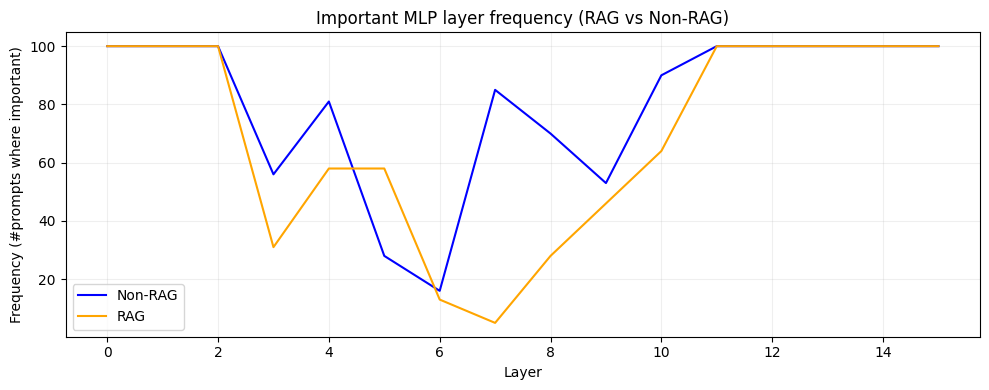

In [ ]:
plot_mlp_layer_freq(rag_mlp_total_counter, non_rag_mlp_total_counter)

Let's try not only to compare RAG versus non-RAG, but also use hard negatives.

In [14]:
def build_nq_faiss_retriever(
    df: pd.DataFrame,
    embed_model_name: str = EMBED_MODEL_NAME,
):
    """
    Builds a FAISS cosine-sim index over the NQ passages (here: df['context']).
    Returns (embedder, index, corpus_texts).
    """
    corpus_texts = df["context"].astype(str).tolist()
    embedder = SentenceTransformer(embed_model_name)

    corpus_emb = embedder.encode(
        corpus_texts, normalize_embeddings=True, batch_size=128, show_progress_bar=True
    ).astype(np.float32)

    index = faiss.IndexFlatIP(corpus_emb.shape[1])  # cosine via normalized dot product
    index.add(corpus_emb)
    return embedder, index, corpus_texts

In [15]:
def retrieve_close_negative(
    embedder,
    index,
    corpus_texts,
    question: str,
    gold_context: str,
    top_k: int = 20,
) -> str | None:
    q_emb = embedder.encode([question], normalize_embeddings=True).astype(np.float32)
    scores, idxs = index.search(q_emb, top_k)
    for j in idxs[0]:
        cand = corpus_texts[int(j)]
        if cand != gold_context:
            return cand
    return None

In [ ]:
def eval_rag_gold_vs_retrieved(
    df: pd.DataFrame,
    hf_model,
    tokenizer,
    embed_model_name: str = "sentence-transformers/all-MiniLM-L6-v2",
    top_k: int = 20,
    batch_size: int = 16,
    max_samples: int | None = None,
) -> pd.DataFrame:
    """
    Filters rows where:
      - RAG with GOLD passage is correct (EM=1)
      - RAG with RETRIEVED passage is incorrect (EM=0)
    """
    df_use = df.copy().reset_index(drop=True)
    if max_samples is not None:
        df_use = df_use.head(max_samples)

    embedder, index, corpus_texts = build_nq_faiss_retriever(df_use, embed_model_name=embed_model_name)

    retrieved_contexts = []
    keep_mask = []
    for _, row in tqdm(df_use.iterrows(), total=len(df_use), desc="Retrieving negatives"):
        neg = retrieve_close_negative(
            embedder, index, corpus_texts,
            question=row["question"],
            gold_context=row["context"],
            top_k=top_k,
        )
        retrieved_contexts.append(neg)
        keep_mask.append(neg is not None)

    df_use["retrieved_context"] = retrieved_contexts
    df_use = df_use[pd.Series(keep_mask).values].reset_index(drop=True)

    gold_prompts = create_prompts_nq(tokenizer, df_use["question"].tolist(), contexts=df_use["context"].tolist())
    ret_prompts  = create_prompts_nq(tokenizer, df_use["question"].tolist(), contexts=df_use["retrieved_context"].tolist())

    gold_preds, ret_preds = [], []
    for i in tqdm(range(0, len(df_use), batch_size), desc="Generating (gold vs retrieved)"):
        gold_batch = gold_prompts[i:i+batch_size]
        ret_batch  = ret_prompts[i:i+batch_size]
        gold_out = generate_batch(hf_model, tokenizer, gold_batch)
        ret_out  = generate_batch(hf_model, tokenizer, ret_batch)
        gold_preds.extend([p.replace("Answer:", "").strip() for p in gold_out])
        ret_preds.extend([p.replace("Answer:", "").strip() for p in ret_out])

    df_use["pred_gold_rag"] = gold_preds
    df_use["pred_ret_rag"] = ret_preds
    df_use["em_gold_rag"] = df_use.apply(lambda r: calculate_exact_match(r["pred_gold_rag"], r["answers"]), axis=1)
    df_use["em_ret_rag"]  = df_use.apply(lambda r: calculate_exact_match(r["pred_ret_rag"],  r["answers"]), axis=1)

    hard_neg_df = df_use[(df_use["em_gold_rag"] == 1) & (df_use["em_ret_rag"] == 0)].reset_index(drop=True)
    return hard_neg_df

In [17]:
# hard_neg_cases.to_pickle("outputs/rag_hard_neg_cases_llama_3_1_1b_nq.pkl")
hard_neg_cases = pd.read_pickle("outputs/rag_hard_neg_cases_llama_3_1_1b_nq.pkl")

In [18]:
hard_neg_cases

,question,answers,context,retrieved_context,pred_gold_rag,pred_ret_rag,em_gold_rag,em_ret_rag
0,who sings does he love me with reba,[Linda Davis],'' Does He Love You '' is a song written by Sa...,'' I Love to Love '' Single by Tina Charles fr...,Linda Davis,Reba,1,0
1,who was the creator of victoria's secret,[Roy Raymond],"Victoria 's Secret Victoria 's Secret Store , ...",In the mid-season finale of the sixth season '...,Roy Raymond,Carrie DiLaurentis,1,0
2,who introduced the system of civil services in...,[Charles Cornwallis],Warren Hastings laid the foundation of civil s...,Delhi had served as the political and financia...,Charles Cornwallis,The British,1,0
3,who is the bad guy in lord of the rings,[Sauron],Sauron / ˈsaʊrɒn / is the title character and ...,"Ian McShane as Beith , the leader of the Dwarv...",Sauron,Snow White,1,0
4,when did bat out of hell get released,[September 1977],Bat Out of Hell is the debut studio album by A...,'' Two Out of Three Ai n't Bad '' is a love so...,September 1977,1977,1,0
...,...,...,...,...,...,...,...,...
169,where did the southern song have their capital,[Lin'an],The Song dynasty is divided into two distinct ...,The song was also the very first musical compo...,Lin'an,Los Angeles,1,0
170,how many platforms does manchester oxford road...,[5],Manchester Oxford Road The Grade - II listed t...,Each club can claim historical supremacy over ...,5,None,1,0
171,who was the jockey that won the triple crown o...,[Victor Espinoza],"Victor Espinoza ( born May 23 , 1972 ) is a jo...","Ranked by height , speed , length , inversions...",Victor Espinoza,Michael Jordan,1,0
172,who has competed in the most world cups,[Brazil],"As of the 2018 FIFA World Cup , 79 national te...",The 21 World Cup tournaments have been won by ...,Brazil,England,1,0


In [34]:
hn_sample = (
    hard_neg_cases
        .assign(context_len=hard_neg_cases["context"].str.len() + hard_neg_cases["retrieved_context"].str.len())
        .sort_values("context_len", ascending=True)
        .head(100)
        .drop(columns="context_len")
        .reset_index(drop=True)
).to_dict(orient='records')

gold_total_heads = collections.defaultdict(int)
neg_total_heads  = collections.defaultdict(int)
gold_unique_heads = collections.defaultdict(int)

for sample in tqdm(hn_sample, desc="Heads: gold RAG vs hard-negative RAG"):
    q = sample["question"]
    gold_ctx = sample["context"]
    neg_ctx  = sample["retrieved_context"]

    gold_prompt, _ = construct_prompts(q, gold_ctx)
    neg_prompt, _  = construct_prompts(q, neg_ctx)

    gold_heads = set(get_important_heads_from_text(model, gold_prompt))
    neg_heads  = set(get_important_heads_from_text(model, neg_prompt))

    for h in gold_heads:
        gold_total_heads[h] += 1
    for h in neg_heads:
        neg_total_heads[h] += 1
    for h in (gold_heads - neg_heads):
        gold_unique_heads[h] += 1

Heads: gold RAG vs hard-negative RAG:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 


--- GOLD vs HARD-NEG (HEADS) ---

TOP HEADS UNIQUE TO GOLD (gold important, neg not)
Layer Head  Frequency   
-----------------------------------
10    23    12          
12    13    11          
4     16    11          
2     21    10          
2     22    9           
8     13    9           
6     15    9           
8     17    9           
5     14    9           
8     19    9           
5     10    8           
3     24    8           
9     19    8           
2     25    8           
7     5     8           

TOP HEADS IN GOLD (TOTAL)
Layer Head  Frequency   
-----------------------------------
4     30    20          
0     23    20          
1     15    20          
1     24    20          
0     7     20          
0     16    20          
0     0     20          
3     17    20          
0     30    20          
0     2     20          
3     28    20          
1     3     20          
1     30    20          
3     30    20          
4     4     20          

TOP HEADS IN H

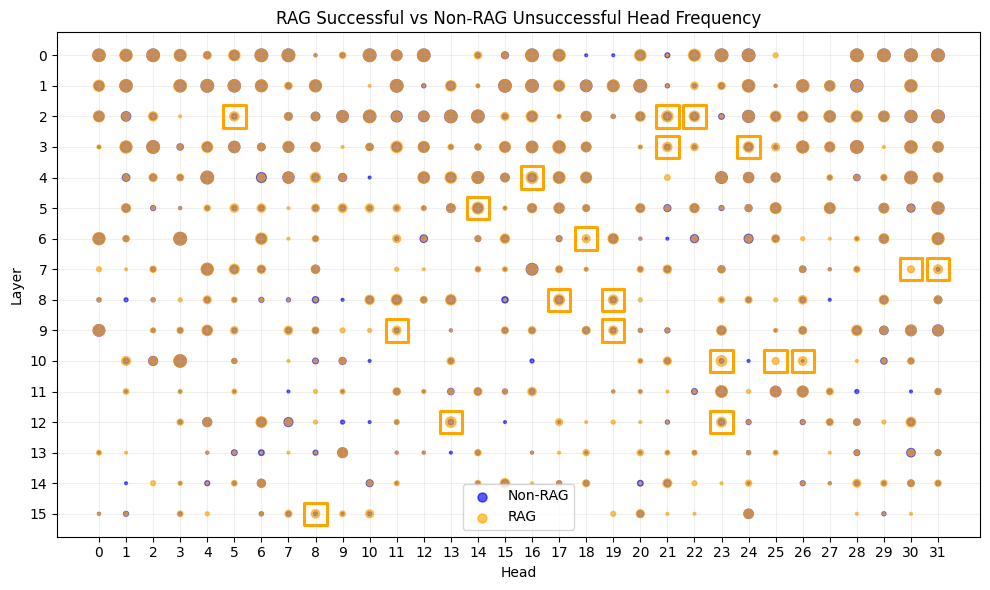

In [26]:
print("\n--- GOLD vs HARD-NEG (HEADS) ---")
save_and_print_top_heads(gold_unique_heads, "TOP HEADS UNIQUE TO GOLD (gold important, neg not)")
save_and_print_top_heads(gold_total_heads, "TOP HEADS IN GOLD (TOTAL)")
save_and_print_top_heads(neg_total_heads, "TOP HEADS IN HARD-NEG (TOTAL)")

plot_top_diff_squares(gold_total_heads, neg_total_heads, top_k=20)

MLPs (last token): gold RAG vs hard-negative RAG:   0%|          | 0/20 [00:00<?, ?it/s]


--- GOLD vs HARD-NEG (MLPs, last token) ---

TOP MLP LAYERS UNIQUE TO GOLD (last token)
Layer  Frequency 
----------------------
8      5         
4      4         
9      3         
6      3         
5      2         
3      2         

TOP MLP LAYERS IN GOLD (TOTAL, last token)
Layer  Frequency 
----------------------
0      20        
1      20        
2      20        
11     20        
12     20        
13     20        
14     20        
15     20        
5      16        
10     12        
4      12        
8      7         
3      6         
9      5         
6      3         

TOP MLP LAYERS IN HARD-NEG (TOTAL, last token)
Layer  Frequency 
----------------------
0      20        
1      20        
2      20        
11     20        
12     20        
13     20        
14     20        
15     20        
5      17        
10     17        
4      12        
3      8         
9      7         
8      4         


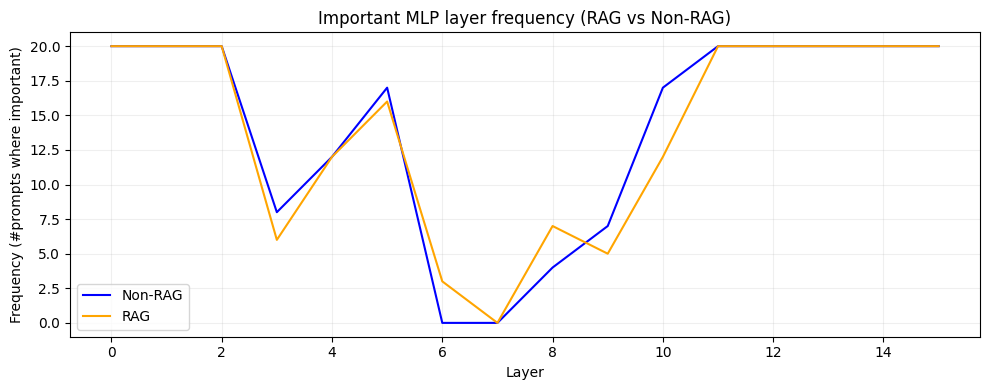

In [33]:
gold_mlp_total = collections.defaultdict(int)
neg_mlp_total  = collections.defaultdict(int)
gold_mlp_unique = collections.defaultdict(int)

for sample in tqdm(hn_sample, desc="MLPs (last token): gold RAG vs hard-negative RAG"):
    q = sample["question"]
    gold_ctx = sample["context"]
    neg_ctx  = sample["retrieved_context"]

    gold_prompt, _ = construct_prompts(q, gold_ctx)
    neg_prompt, _  = construct_prompts(q, neg_ctx)

    gold_mlps = set(get_important_mlps_last_token(model, gold_prompt))
    neg_mlps  = set(get_important_mlps_last_token(model, neg_prompt))

    for l in gold_mlps:
        gold_mlp_total[l] += 1
    for l in neg_mlps:
        neg_mlp_total[l] += 1
    for l in (gold_mlps - neg_mlps):
        gold_mlp_unique[l] += 1

print("\n--- GOLD vs HARD-NEG (MLPs, last token) ---")
print_top_mlps(gold_mlp_unique, "TOP MLP LAYERS UNIQUE TO GOLD (last token)")
print_top_mlps(gold_mlp_total, "TOP MLP LAYERS IN GOLD (TOTAL, last token)")
print_top_mlps(neg_mlp_total, "TOP MLP LAYERS IN HARD-NEG (TOTAL, last token)")

plot_mlp_layer_freq(gold_mlp_total, neg_mlp_total)